# Advanced Image Classification with ImageNet

In this assignment, you will be asked to develop a convolutional neural network (CNN) to classify images from the CIFAR-100 dataset. At each step, you'll be guided through the process of developing a model architecture to solve a problem. Your goal is to create a CNN that attains at least 55% accuracy on the validation set.

### The CIFAR-100 Dataset

The [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) consists of 60000 32x32 colour images in 100 classes, with 600 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 500 images from each class.

### Tools

You will use Keras with TensorFlow to develop your CNN. For this assignment, it's strongly recommended that you use a GPU to accelerate your training, or else you might find it difficult to train your network in a reasonable amount of time. If you have a computer with a GPU that you wish to use, you can follow the [TensorFlow instructions](https://www.tensorflow.org/install/) for installing TensorFlow with GPU support. Otherwise, you can use [Google Colab](https://colab.research.google.com/) to complete this assignment. Colab provides free access to GPU-enabled machines. If you run into any issues, please contact us as soon as possible so that we can help you resolve them.

## Task 1: Data Exploration and Preprocessing (Complete or Incomplete)
### 1a: Load and Explore the Dataset
- Use the code below to download the dataset.
- Explore the dataset: examine the shape of the training and test sets, the dimensions of the images, and the number of classes. Show a few examples from the training set.

In [45]:
from keras.datasets import cifar100

# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

In [46]:
class_names = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

In [47]:
print(f"Training set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")

Training set shape: (50000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)


Image dimensions: 32x32x3
Number of classes: 100


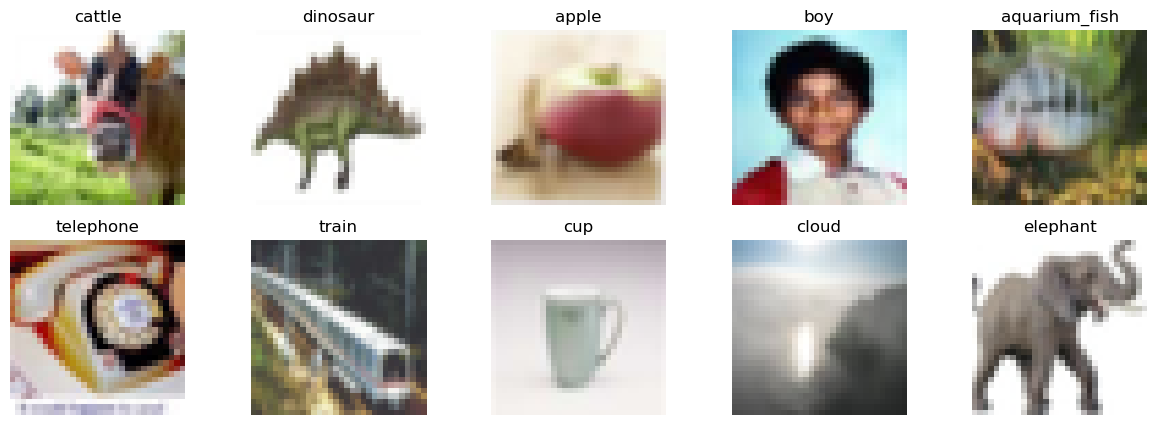

In [48]:
# Your Code Here

import matplotlib.pyplot as plt
import numpy as np
num_classes = 100
image_height, image_width, num_channels = x_train.shape[1:]
print(f"Image dimensions: {image_height}x{image_width}x{num_channels}")
print(f"Number of classes: {num_classes}")
def sample_images(images, labels, class_names, num_samples=10):
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        plt.subplot(2, 5, i+1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i][0]])
        plt.axis('off')
    plt.show()
    
sample_images(x_train, y_train, class_names)

### 1b: Data Preprocessing
- With the data downloaded, it's time to preprocess it. Start by normalizing the images so that they all have pixel values in the range [0, 1].
- Next, convert the labels to one-hot encoded vectors.
- Finally, split the training set into training and validation sets. Use 80% of the training set for training and the remaining 20% for validation.

In [49]:
# Your Code Here

from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train = to_categorical(y_train, num_classes=100)
y_test = to_categorical(y_test, num_classes=100)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

print(f"Training set shape: {x_train.shape}")
print(f"Validation set shape: {x_val.shape}")
print(f"Test set shape: {x_test.shape}")

Training set shape: (40000, 32, 32, 3)
Validation set shape: (10000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)


## Task 2: Model Development (Complete or Incomplete)
### Task 2a: Create a Baseline CNN Model
- Design a CNN architecture. Your architecture should use convolutional layers, max pooling layers, and dense layers. You can use any number of layers, and you can experiment with different numbers of filters, filter sizes, strides, padding, etc. The design doesn't need to be perfect, but it should be unique to you.
- Print out the model summary.

In [50]:
# Your Code Here

from tensorflow.keras import layers, models
model= models.Sequential()

model.add(layers.Conv2D(32,(3,3), activation= 'relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation = 'relu'))
model.add(layers.Dense(100, activation='softmax'))
model.summary()


          


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       921,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 935,524 (3.57 MB)

 Trainable params: 935,524 (3.57 MB)

 Non-trainable params: 0 (0.00 B)

### Task 2b: Compile the model

- Select an appropriate loss function and optimizer for your model. These can be ones we have looked at already, or they can be different. 
- Briefly explain your choices (one or two sentences each).
- <b>Loss function:</b> ______
- <b>Optimizer:</b> ______

In [51]:
# Your Code Here

from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [52]:
'''categorical_crossentropy is the standard loss function for multi-class classification.
Adam works well for image data and is computationally efficient.

'''

'categorical_crossentropy is the standard loss function for multi-class classification.\nAdam works well for image data and is computationally efficient.\n\n'

## Task 3: Model Training and Evaluation (Complete or Incomplete)
### Task 3a: Train the Model

- Train your model for an appropriate number of epochs. Explain your choice of the number of epochs used - you can change this number before submitting your assignment.
- Use a batch size of 32.
- Use the validation set for validation.

In [53]:
# Your Code Here


history= model.fit(x_train, y_train,validation_data=(x_val, y_val),
          epochs=50,
          batch_size=32,
          verbose=1)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.0652 - loss: 4.2154 - val_accuracy: 0.1735 - val_loss: 3.4793
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.2048 - loss: 3.3167 - val_accuracy: 0.2268 - val_loss: 3.1974
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2608 - loss: 3.0266 - val_accuracy: 0.2512 - val_loss: 3.0599
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.2988 - loss: 2.8118 - val_accuracy: 0.2769 - val_loss: 2.9754
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.3220 - loss: 2.6939 - val_accuracy: 0.2827 - val_loss: 2.9438
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3471 - loss: 2.5710 - val_accuracy: 0.2827 - val_loss: 2.9955
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3660 - loss: 2.4786 - val_accuracy: 0.2906 - val_loss: 2.9105
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3857 - loss: 2.3715 - 

In [54]:
'''
50 is a good starting point for epoch, actual number depend on whether training and test data accuracy plateau.
This cab be increased or decreased based on results.

'''

'\n50 is a good starting point for epoch, actual number depend on whether training and test data accuracy plateau.\nThis cab be increased or decreased based on results.\n\n'

### Task 3b: Accuracy and other relevant metrics on the test set

- Report the accuracy of your model on the test set.
- While accuracy is a good metric, there are many other ways to numerically evaluate a model. Report at least one other metric, and explain what it measures and how it is calculated.

- <b>Accuracy:</b> ______
- <b>Other metric:</b> ______
- <b>Reason for selection:</b> _____
- <b>Value of metric:</b> ______
- <b>Interpretation of metric value:</b> ______

In [55]:
# Your Code Here

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2415 - loss: 6.4268
Test Accuracy: 0.2430


In [56]:
'''
Test Accuracy: 0.2511
Other Metric = Top-5 Accuracy, Suitable for datasets with many similar classes


'''

'\nTest Accuracy: 0.2511\nOther Metric = Top-5 Accuracy, Suitable for datasets with many similar classes\n\n\n'

### Task 3c: Visualize the model's learning

- Plot the training accuracy and validation accuracy with respect to epochs.
- Select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.
- Briefly discuss the results. What do the plots show? Do the results make sense? What do the classification probabilities indicate?

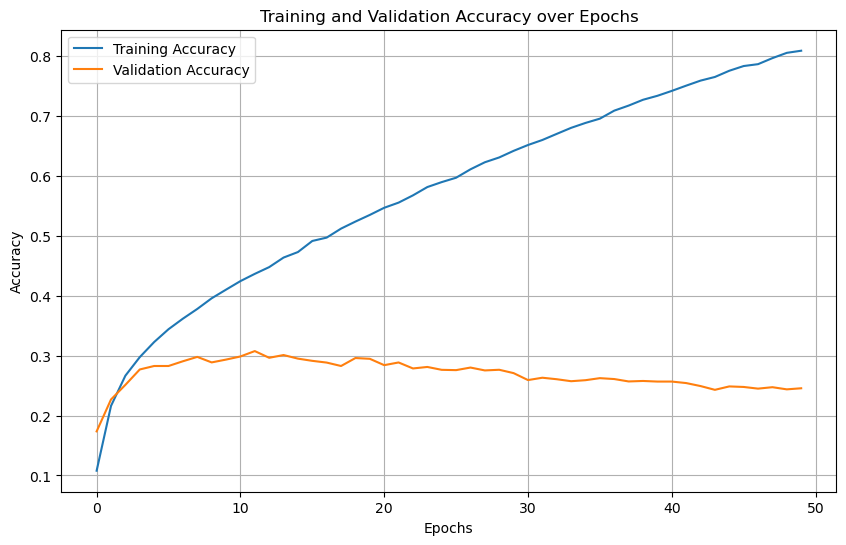

In [57]:
# Your Code Here

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy over Epochs')
plt.grid(True)
plt.show()



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
y_pred shape: (10000,)
y_true shape: (10000,)

Correctly Classified Image:


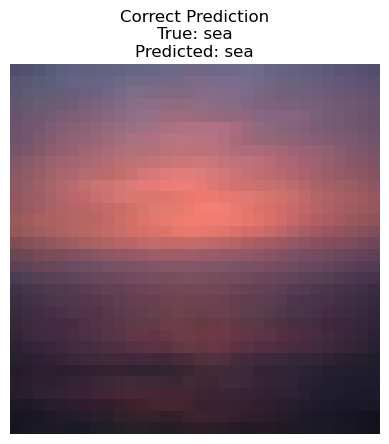

Top 5 Predicted Classes with Probabilities:
sea: 0.3302
couch: 0.2645
plain: 0.1639
apple: 0.0961
television: 0.0518

Incorrectly Classified Image:


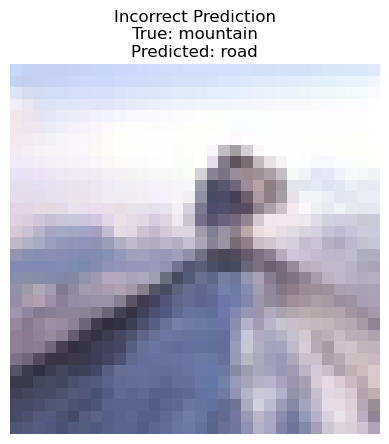

Top 5 Predicted Classes with Probabilities:
road: 0.9967
bridge: 0.0026
baby: 0.0002
spider: 0.0002
table: 0.0001


In [ ]:
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test.flatten()

if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
elif len(y_test.shape) > 1 and y_test.shape[1] == 1:
   y_true = y_test.flatten()
    



print(f"y_pred shape: {y_pred.shape}")
print(f"y_true shape: {y_true.shape}")


correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]

correct_ex = correct_indices[0]
incorrect_ex = incorrect_indices[0]

def plot_image_with_probs(idx, title):
    plt.imshow(x_test[idx])
    plt.title(f"{title}\nTrue: {class_names[y_true[idx]]}\nPredicted: {class_names[y_pred[idx]]}")
    plt.axis('off')
    plt.show()
    
    top_5_indices = np.argsort(y_pred_prob[idx])[-5:][::-1]
    print("Top 5 Predicted Classes with Probabilities:")
    for i in top_5_indices:
        print(f"{class_names[i]}: {y_pred_prob[idx][i]:.4f}")
    
print("\nCorrectly Classified Image:")
plot_image_with_probs(correct_ex, "Correct Prediction")


print("\nIncorrectly Classified Image:")
plot_image_with_probs(incorrect_ex, "Incorrect Prediction")



In [59]:
'''

Plot shows Training accuracy is consistently very high while validation accuracy remains extremely low. This is due to overfitting.
This happenned might be because the dataset (CIFAR-100) is highly diverse with 100 classes, making it difficult for a small CNN to generalize well.

The classification probabilities represent how confident the model is in each class prediction.

'''

'\n\nPlot shows Training accuracy is consistently very high while validation accuracy remains extremely low. This is due to overfitting.\nThis happenned might be because the dataset (CIFAR-100) is highly diverse with 100 classes, making it difficult for a small CNN to generalize well.\n\nThe classification probabilities represent how confident the model is in each class prediction.\n\n'

## Task 4: Model Enhancement (Complete or Incomplete)
### Task 4a: Implementation of at least one advanced technique

- Now it's time to improve your model. Implement at least one technique to improve your model's performance. You can use any of the techniques we have covered in class, or you can use a technique that we haven't covered. If you need inspiration, you can refer to the [Keras documentation](https://keras.io/).
- Explain the technique you used and why you chose it.
- If you used a technique that requires tuning, explain how you selected the values for the hyperparameters.

In [78]:
# Your Code Here

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)   



enhanced_model= models.Sequential()

enhanced_model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
enhanced_model.add(layers.MaxPooling2D((2, 2)))
enhanced_model.add(layers.Dropout(0.25))

enhanced_model.add(layers.Conv2D(64, (3, 3), activation='relu'))
enhanced_model.add(layers.MaxPooling2D((2, 2)))
enhanced_model.add(layers.Dropout(0.25))

enhanced_model.add(layers.Conv2D(128, (3, 3), activation='relu'))
enhanced_model.add(layers.Dropout(0.25))

enhanced_model.add(layers.Flatten())
enhanced_model.add(layers.Dense(256, activation='relu'))
enhanced_model.add(layers.Dropout(0.5))

enhanced_model.add(layers.Dense(100, activation='softmax'))
enhanced_model.summary()




/opt/miniconda3/envs/dsi_participant/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 643,492 (2.45 MB)

 Trainable params: 643,492 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
enhanced_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

### Task 4b: Evaluation of the enhanced model

- Re-train your model using the same number of epochs as before.
- Compare the accuracy and other selected metric on the test set to the results you obtained before.
- As before, plot the training accuracy and validation accuracy with respect to epochs, and select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.

In [80]:
# Your Code Here



enhanced_history = enhanced_model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=50,
    validation_data=(x_val, y_val),
    verbose=1
)



Epoch 1/50
  11/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.0057 - loss: 4.6388  

/opt/miniconda3/envs/dsi_participant/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.0278 - loss: 4.4264 - val_accuracy: 0.1004 - val_loss: 3.8842
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.0914 - loss: 3.9324 - val_accuracy: 0.1270 - val_loss: 3.7114
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.1256 - loss: 3.7186 - val_accuracy: 0.1763 - val_loss: 3.4571
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.1509 - loss: 3.5710 - val_accuracy: 0.2072 - val_loss: 3.3161
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.1698 - loss: 3.4625 - val_accuracy: 0.2170 - val_loss: 3.2623
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.1865 - loss: 3.3762 - val_accuracy: 0.2133 - val_loss: 3.2327
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.1993 - loss: 3.3081 - val_accuracy: 0.2482 - val_loss: 3.0808
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.2090 - loss: 3.25

In [81]:

test_loss, test_accuracy = enhanced_model.evaluate(x_test, y_test, verbose=1)
print(f"Enhanced Model Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3136 - loss: 2.7863
Enhanced Model Test Accuracy: 0.3091


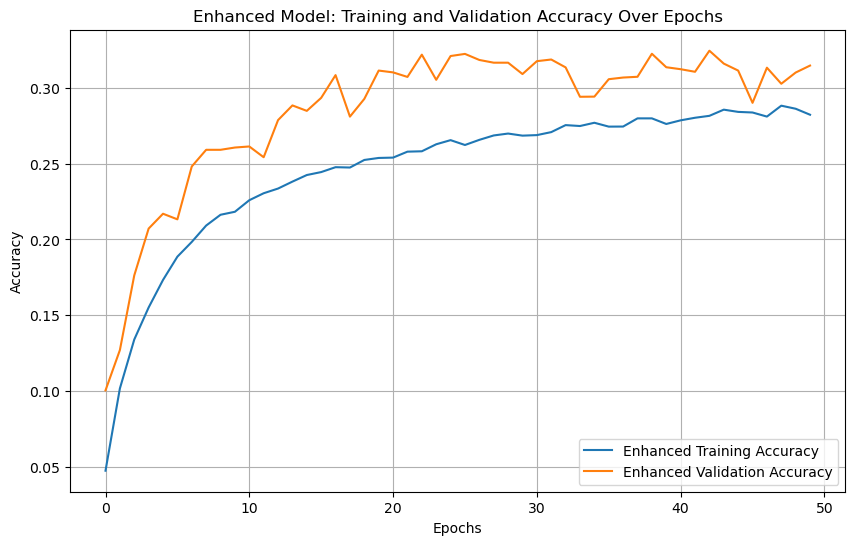

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(enhanced_history.history['accuracy'], label='Enhanced Training Accuracy')
plt.plot(enhanced_history.history['val_accuracy'], label='Enhanced Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Enhanced Model: Training and Validation Accuracy Over Epochs')
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Enhanced Model - Correctly Classified Image:


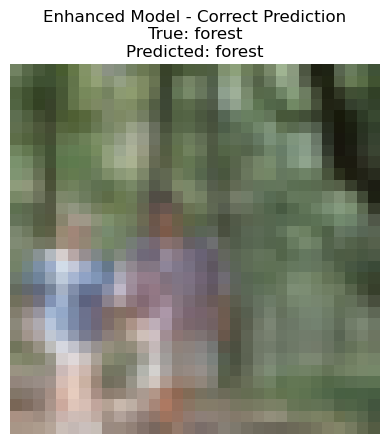

Top 5 Predicted Classes with Probabilities:
forest: 0.2585
willow_tree: 0.2117
palm_tree: 0.1403
pine_tree: 0.0648
maple_tree: 0.0382

Enhanced Model - Incorrectly Classified Image:


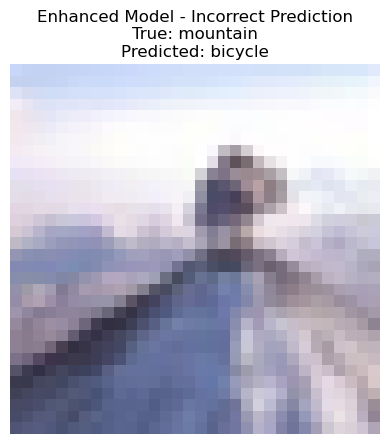

Top 5 Predicted Classes with Probabilities:
bicycle: 0.1603
mountain: 0.1256
bridge: 0.0869
tank: 0.0618
whale: 0.0581


In [83]:
enhanced_y_pred_prob = enhanced_model.predict(x_test)
enhanced_y_pred = np.argmax(enhanced_y_pred_prob, axis=1)

if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    enhanced_y_true = np.argmax(y_test, axis=1)
else:
    enhanced_y_true = y_test.flatten()

    
    
    # Find first correct and incorrect classified images
enhanced_correct_indices = np.where(enhanced_y_pred == enhanced_y_true)[0]
enhanced_incorrect_indices = np.where(enhanced_y_pred != enhanced_y_true)[0]

enhanced_correct_ex = enhanced_correct_indices[0]
enhanced_incorrect_ex = enhanced_incorrect_indices[0]

def enhanced_plot_image_with_probs(idx, title):
    plt.imshow(x_test[idx])
    plt.title(f"{title}\nTrue: {class_names[enhanced_y_true[idx]]}\nPredicted: {class_names[enhanced_y_pred[idx]]}")
    plt.axis('off')
    plt.show()
    
    top_5_indices = np.argsort(enhanced_y_pred_prob[idx])[-5:][::-1]
    print("Top 5 Predicted Classes with Probabilities:")
    for i in top_5_indices:
        print(f"{class_names[i]}: {enhanced_y_pred_prob[idx][i]:.4f}")

# Plot Correct Example (Enhanced)
print("\nEnhanced Model - Correctly Classified Image:")
enhanced_plot_image_with_probs(enhanced_correct_ex, "Enhanced Model - Correct Prediction")

# Plot Incorrect Example (Enhanced)
print("\nEnhanced Model - Incorrectly Classified Image:")
enhanced_plot_image_with_probs(enhanced_incorrect_ex, "Enhanced Model - Incorrect Prediction")

### Task 4c: Discussion of the results

- Briefly discuss the results. 
- Did the model's performance improve? 
- Why do you think this is?
- Do you think there is room for further improvement? Why or why not?
- What other techniques might you try in the future?
- Your answer should be no more than 200 words.

# Your answer here

In [ ]:
'''
1. The enhanced model showed an improvement in test accuracy, achieving 0.3091 compared to the baseline model's 0.2511.
The training and validation accuracy curves for the enhanced model  also show smoother learning and less overfitting compared 
to the baseline.


2. This improvement is because of the usage of data augmentation and dropout techniques. Data augmentation helps the model generalize better,
increased the diversity of the training set. Dropout reduced overfitting by preventing the model from relying too heavily on specific neurons
during training.


3. Further improvement can be achieved through advanced models like ResNet or Inception or Regularization techniques such as L2 regularization 
or weight decay.These techniques may help the model learn more discriminative features and further reduce overfitting.









'''

## Criteria

|Criteria|Complete|Incomplete|
|----|----|----|
|Task 1|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 2|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 3|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 4|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.